In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train = pd.read_parquet(
    "data/artifacts/03_train1.parquet"
)

print("Shape:", train.shape)
display(train.head())

Shape: (67529, 42)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_lat,customer_lng,...,total_product_volume_cm3,avg_product_photos_qty,avg_product_name_length,avg_product_description_length,seller_customer_distance_km,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,is_delayed
0,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04,-20.585396,-47.863156,...,12288.0,1.0,34.0,1036.0,566.040211,830d5b7aaa3b6f1e9ad63703bec97d23,14600,sao joaquim da barra,SP,1
1,3b697a20d9e427646d92567910af6d57,355077684019f7f60a031656bd7262b8,delivered,2016-10-03 09:44:50,2016-10-06 15:50:54,2016-10-23 14:02:13,2016-10-26 14:02:13,2016-10-27,-23.581321,-46.635726,...,4096.0,3.0,63.0,1642.0,708.535291,32ea3bdedab835c3aa6cb68ce66565ef,4106,sao paulo,SP,0
2,be5bc2f0da14d8071e2d45451ad119d9,7ec40b22510fdbea1b08921dd39e63d8,delivered,2016-10-03 16:56:50,2016-10-06 16:03:44,2016-10-21 16:33:46,2016-10-27 18:19:38,2016-11-07,-28.291275,-53.501401,...,4096.0,1.0,39.0,518.0,915.734331,2f64e403852e6893ae37485d5fcacdaf,98280,panambi,RS,0
3,a41c8759fbe7aab36ea07e038b2d4465,6f989332712d3222b6571b1cf5b835ce,delivered,2016-10-03 21:13:36,2016-10-05 03:11:49,2016-10-25 11:57:59,2016-11-03 10:58:07,2016-11-29,-30.040958,-51.212970,...,4160.0,1.0,39.0,141.0,818.048765,61db744d2f835035a5625b59350c6b63,90040,porto alegre,RS,0
4,d207cc272675637bfed0062edffd0818,b8cf418e97ae795672d326288dfab7a7,delivered,2016-10-03 22:06:03,2016-10-04 10:28:07,2016-10-21 14:23:37,2016-10-31 11:07:42,2016-11-23,-22.894390,-47.173213,...,14960.0,1.0,55.0,130.0,212.149919,8d3a54507421dbd2ce0a1d58046826e0,13185,hortolandia,SP,0


In [2]:
train.info()
print(train.dtypes)
print(train.shape)
print(train.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67529 entries, 0 to 67528
Data columns (total 42 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   order_id                        67529 non-null  object        
 1   customer_id                     67529 non-null  object        
 2   order_status                    67529 non-null  object        
 3   order_purchase_timestamp        67529 non-null  datetime64[ns]
 4   order_approved_at               67515 non-null  datetime64[ns]
 5   order_delivered_carrier_date    67528 non-null  datetime64[ns]
 6   order_delivered_customer_date   67529 non-null  datetime64[ns]
 7   order_estimated_delivery_date   67529 non-null  datetime64[ns]
 8   customer_lat                    67348 non-null  float64       
 9   customer_lng                    67348 non-null  float64       
 10  customer_geo_points             67348 non-null  float64       
 11  se

In [18]:
print("Target distribution:")
print(train["is_delayed"].value_counts())

print("\nTarget percentage:")
print(
    train["is_delayed"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Target distribution:
is_delayed
0    61433
1     6096
Name: count, dtype: int64

Target percentage:
is_delayed
0    90.97
1     9.03
Name: proportion, dtype: float64


In [3]:
train_eda = train.copy()

train_eda["purchase_month"] = (
    train_eda["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

monthly_delay = (
    train_eda
    .groupby("purchase_month")["is_delayed"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

monthly_delay["delay_rate"] = (
    monthly_delay["mean"] * 100
).round(2)

monthly_delay.head(10)

,purchase_month,count,sum,mean,delay_rate
0,2016-09,1,1,1.000000,100.00
1,2016-10,265,3,0.011321,1.13
2,2016-12,1,0,0.000000,0.00
3,2017-01,750,23,0.030667,3.07
4,2017-02,1653,53,0.032063,3.21
5,2017-03,2546,142,0.055774,5.58
6,2017-04,2303,181,0.078593,7.86
7,2017-05,3545,128,0.036107,3.61
8,2017-06,3135,121,0.038596,3.86
9,2017-07,3872,133,0.034349,3.43


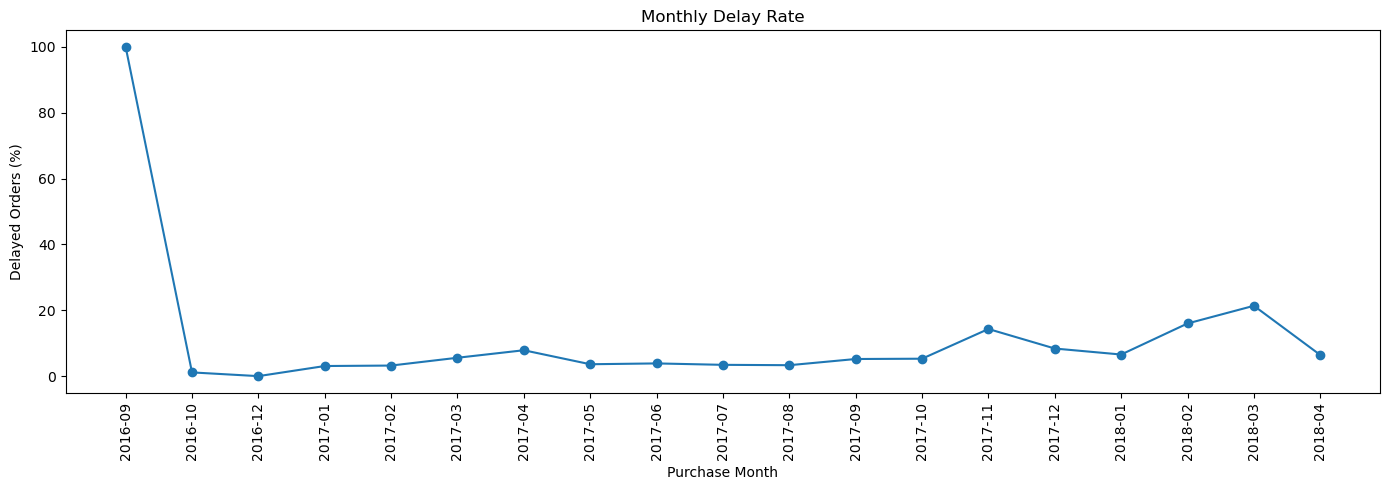

In [20]:
import os

os.makedirs(
    "data/artifacts/eda",
    exist_ok=True
)
plt.figure(figsize=(14, 5))

plt.plot(
    monthly_delay["purchase_month"],
    monthly_delay["delay_rate"],
    marker="o"
)

plt.xticks(rotation=90)
plt.xlabel("Purchase Month")
plt.ylabel("Delayed Orders (%)")
plt.title("Monthly Delay Rate")
plt.tight_layout()
plt.savefig(
    "data/artifacts/eda/Monthly_Delay_Rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [4]:
train_eda["purchase_dayofweek"] = (
    train_eda["order_purchase_timestamp"].dt.dayofweek
)

day_delay = (
    train_eda
    .groupby("purchase_dayofweek")["is_delayed"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

day_delay["delay_rate"] = (
    day_delay["mean"] * 100
).round(2)

day_delay

,purchase_dayofweek,count,sum,mean,delay_rate
0,0,10734,1075,0.100149,10.01
1,1,10729,994,0.092646,9.26
2,2,10339,890,0.086082,8.61
3,3,10005,829,0.082859,8.29
4,4,9884,936,0.094699,9.47
5,5,7593,681,0.089688,8.97
6,6,8245,691,0.083808,8.38


In [6]:
numerical_features = [
    "customer_lat",
    "customer_lng",
    "seller_lat",
    "seller_lng",
    "customer_geo_points",
    "seller_geo_points",
    "num_sellers",
    "num_seller_states",
    "num_seller_cities",
    "total_price",
    "total_freight",
    "num_items",
    "num_unique_products",
    "num_unique_sellers",
    "total_payment",
    "num_payment_records",
    "num_payment_types",
    "avg_review_score",
    "num_reviews",
    "avg_product_weight_g",
    "total_product_weight_g",
    "avg_product_length_cm",
    "avg_product_height_cm",
    "avg_product_width_cm",
    "total_product_volume_cm3",
    "avg_product_photos_qty",
    "avg_product_name_length",
    "avg_product_description_length",
    "seller_customer_distance_km"
]

print("Number of numerical features:", len(numerical_features))

Number of numerical features: 29


In [7]:
numerical_summary = train_eda[numerical_features].describe().T

numerical_summary

,count,mean,std,min,25%,50%,75%,max
customer_lat,67348.0,-21.132372,5.709291,-33.690972,-23.588015,-22.915533,-19.996322,4.114620e+01
customer_lng,67348.0,-46.177341,4.120320,-72.670987,-48.271715,-46.627314,-43.533454,-8.577855e+00
seller_lat,67365.0,-22.844041,2.482897,-32.074657,-23.613259,-23.416531,-21.757690,-2.498944e+00
seller_lng,67365.0,-47.273689,2.334401,-63.893145,-48.829768,-46.755492,-46.522148,-3.485512e+01
customer_geo_points,67348.0,153.231128,153.688365,1.000000,53.000000,103.000000,196.000000,1.146000e+03
seller_geo_points,67529.0,167.290157,174.016005,0.000000,60.000000,123.000000,236.000000,4.638000e+03
num_sellers,67529.0,1.012054,0.114815,1.000000,1.000000,1.000000,1.000000,5.000000e+00
num_seller_states,67529.0,1.004679,0.069323,1.000000,1.000000,1.000000,1.000000,3.000000e+00
num_seller_cities,67529.0,1.009389,0.100352,1.000000,1.000000,1.000000,1.000000,4.000000e+00
total_price,67529.0,135.888797,205.194019,2.290000,45.900000,85.000000,149.900000,1.344000e+04


In [8]:
skewness = (
    train_eda[numerical_features]
    .skew()
    .sort_values(ascending=False)
)

skewness

num_payment_records               22.419509
num_seller_states                 15.177527
num_reviews                       11.886516
num_seller_cities                 11.470732
total_price                       10.718895
num_unique_sellers                10.524938
num_sellers                       10.524938
total_payment                     10.149318
total_freight                      8.581743
num_items                          8.107162
num_unique_products                7.677312
total_product_volume_cm3           7.555892
total_product_weight_g             6.644615
num_payment_types                  6.217627
seller_geo_points                  4.668321
avg_product_weight_g               3.579216
customer_geo_points                2.278180
avg_product_height_cm              2.213589
seller_lat                         2.092667
avg_product_description_length     2.076959
avg_product_photos_qty             1.938194
avg_product_width_cm               1.726564
avg_product_length_cm           

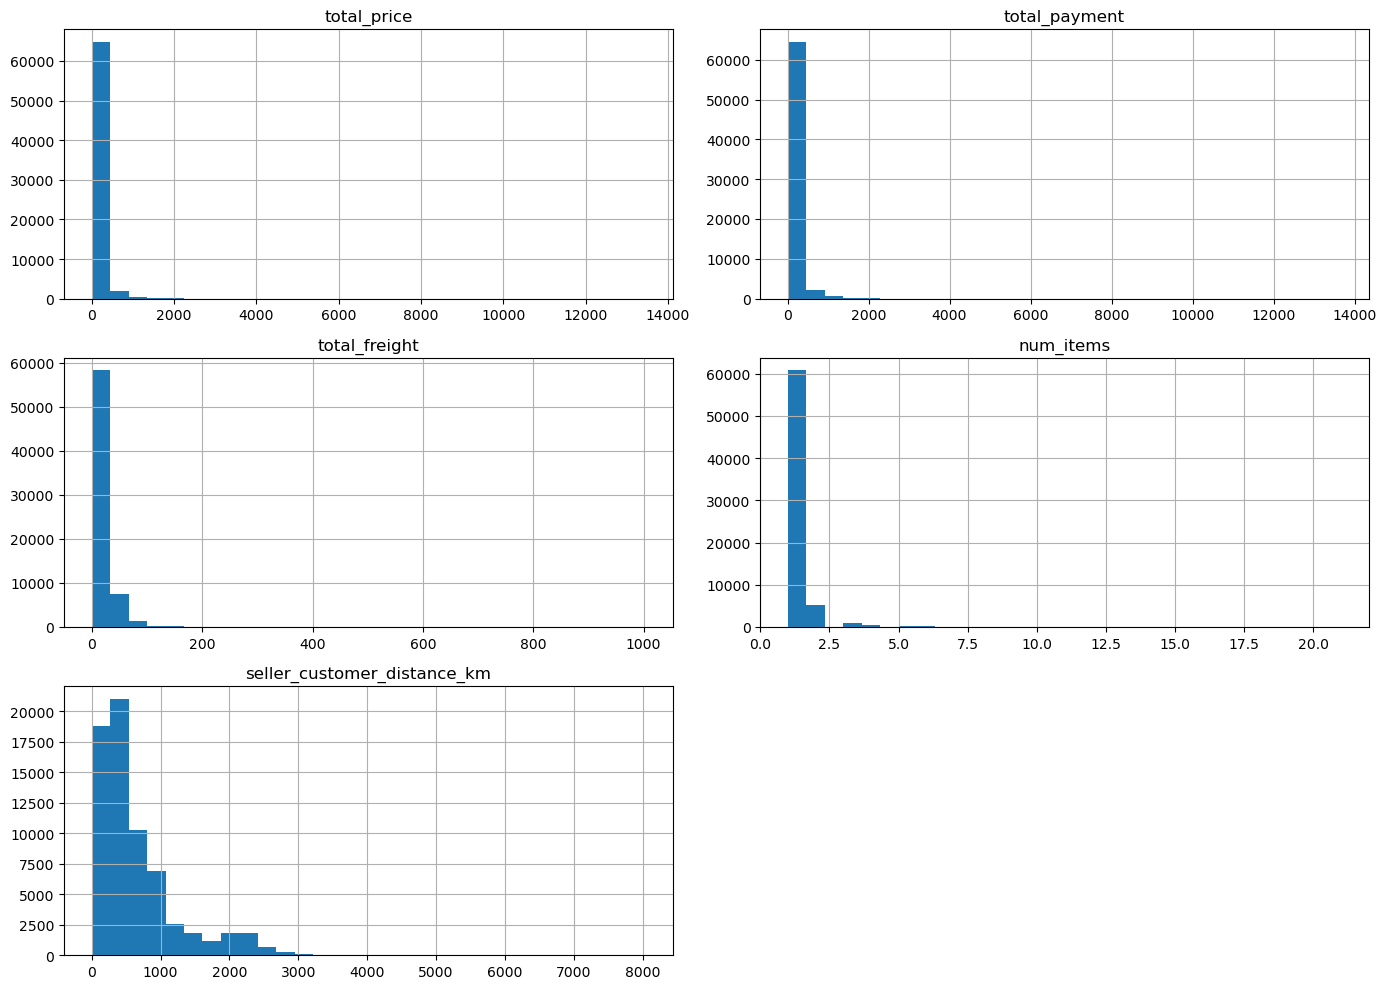

In [25]:
highly_skewed_features = [
    "total_price",
    "total_payment",
    "total_freight",
    "num_items",
    "seller_customer_distance_km"
]

train_eda[highly_skewed_features].hist(
    bins=30,
    figsize=(14, 10)
)

plt.tight_layout()
plt.show()

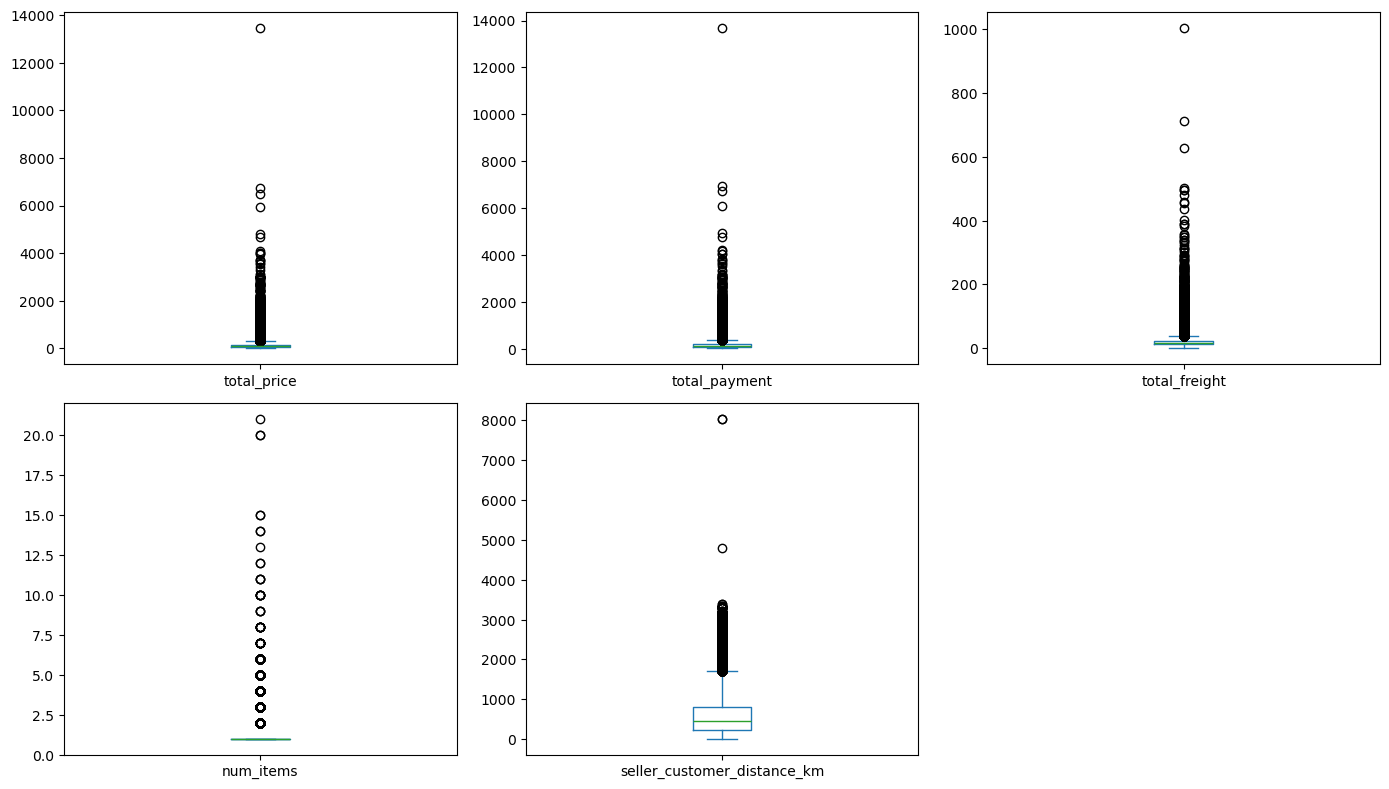

In [26]:
import matplotlib.pyplot as plt

train_eda[highly_skewed_features].plot(
    kind="box",
    subplots=True,
    layout=(2, 3),
    figsize=(14, 8)
)

plt.tight_layout()
plt.show()

In [27]:
for feature in highly_skewed_features:
    Q1 = train_eda[feature].quantile(0.25)
    Q3 = train_eda[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = train_eda[
        (train_eda[feature] < lower_bound) |
        (train_eda[feature] > upper_bound)
    ]

    print(f"\n{feature}")
    print("Q1:", round(Q1, 2))
    print("Q3:", round(Q3, 2))
    print("Upper bound:", round(upper_bound, 2))
    print("Number of outliers:", len(outliers))


total_price
Q1: 45.9
Q3: 149.9
Upper bound: 305.9
Number of outliers: 5362

total_payment
Q1: 61.63
Q3: 175.5
Upper bound: 346.3
Number of outliers: 5309

total_freight
Q1: 14.1
Q3: 23.7
Upper bound: 38.1
Number of outliers: 6630

num_items
Q1: 1.0
Q3: 1.0
Upper bound: 1.0
Number of outliers: 6758

seller_customer_distance_km
Q1: 218.16
Q3: 810.66
Upper bound: 1699.42
Number of outliers: 5447


In [7]:
categorical_features = train_eda.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Number of categorical features:", len(categorical_features))
print(categorical_features)

Number of categorical features: 7
['order_id', 'customer_id', 'order_status', 'customer_unique_id', 'customer_city', 'customer_state', 'purchase_month']


In [8]:
for col in categorical_features:
    print(f"\n{'='*60}")
    print(f"Column: {col}")
    print(f"Unique values: {train_eda[col].nunique()}")
    print(f"Missing values: {train_eda[col].isna().sum()}")
    print("Top 10 values:")
    print(train_eda[col].value_counts(dropna=False).head(10))


Column: order_id
Unique values: 67529
Missing values: 0
Top 10 values:
order_id
bfbd0f9bdef84302105ad712db648a6c    1
7a3dbfe3daed55f0b5f34c4f9e73940a    1
75e7e33e52d884da90b436ae1da13be5    1
dba3d308cfb77b3fcc46a50e560080bb    1
77fc7da5ef4df2c48276ae832072dcf1    1
0fedd03057d5e595d8f337fc2be6fe25    1
af18dcad5c76de4eec9a63dfc1672296    1
5fd641e5e16c3b056b1fb4dd6e429c43    1
94726dd6ee359e6b201305165dac1d5b    1
a824974b8e61d6186b2850a63ca9461e    1
Name: count, dtype: int64

Column: customer_id
Unique values: 67529
Missing values: 0
Top 10 values:
customer_id
86dc2ffce2dfff336de2f386a786e574    1
d58d9b632ba93e5f55f80feef49b0d94    1
0127d98d4a7e205081ddac271d6b8e52    1
f19f11ddfa4f4d61154a277408a98d0c    1
a260ca264a1787a1842ced2735bff664    1
784448d59180b2b8f5624e0d13267b34    1
285061238e7b7f6095975a7c36322e05    1
4948d9d11ebcd4d241a0b291c15d5779    1
f766d9a5d297c1426e53c4301ddfab23    1
a4a6c746d0fc091842d5dd44bb22d754    1
Name: count, dtype: int64

Column: order_statu

In [9]:
state_delay = (
    train_eda.groupby("customer_state")["is_delayed"]
    .agg(["count", "mean", "sum"])
    .sort_values("mean", ascending=False)
)

state_delay

,count,mean,sum
customer_state,,,
AL,298,0.278523,83
MA,548,0.215328,118
CE,948,0.182489,173
RR,29,0.172414,5
SE,246,0.170732,42
PI,348,0.166667,58
RJ,8965,0.165867,1487
BA,2307,0.149978,346
PA,718,0.133705,96


In [11]:
city_summary = (
    train_eda.groupby("customer_city")["is_delayed"]
    .agg(["count", "mean", "sum"])
    .sort_values("count", ascending=False)
)

display(city_summary.head(20))

print("Number of unique cities:", train_eda["customer_city"].nunique())

,count,mean,sum
customer_city,,,
sao paulo,9920,0.056048,556
rio de janeiro,4777,0.147792,706
belo horizonte,1869,0.069021,129
brasilia,1395,0.080287,112
curitiba,1020,0.053922,55
porto alegre,975,0.139487,136
campinas,967,0.113754,110
salvador,823,0.195626,161
guarulhos,724,0.060773,44


Number of unique cities: 3747


In [12]:
city_counts = train_eda["customer_city"].value_counts()

print("Cities with 1 order:", (city_counts == 1).sum())
print("Cities with <= 5 orders:", (city_counts <= 5).sum())
print("Cities with <= 10 orders:", (city_counts <= 10).sum())
print("Cities with <= 20 orders:", (city_counts <= 20).sum())

Cities with 1 order: 1219
Cities with <= 5 orders: 2630
Cities with <= 10 orders: 3058
Cities with <= 20 orders: 3324


In [13]:
print("Percentage of cities with <= 5 orders:",
      (city_counts <= 5).mean() * 100)

print("Percentage of cities with <= 10 orders:",
      (city_counts <= 10).mean() * 100)

Percentage of cities with <= 5 orders: 70.18948492127035
Percentage of cities with <= 10 orders: 81.61195623165199


In [14]:
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

print("Date columns summary:")
print(train_eda[date_cols].dtypes)

print("\nMissing values:")
display(train_eda[date_cols].isna().sum())

# Purchase time features for EDA
train_eda["purchase_weekday"] = train_eda["order_purchase_timestamp"].dt.day_name()
train_eda["purchase_month_num"] = train_eda["order_purchase_timestamp"].dt.month
train_eda["purchase_hour"] = train_eda["order_purchase_timestamp"].dt.hour

print("\nDelay rate by purchase weekday:")
display(
    train_eda.groupby("purchase_weekday")["is_delayed"]
    .agg(["count", "mean", "sum"])
)

print("\nDelay rate by purchase month:")
display(
    train_eda.groupby("purchase_month_num")["is_delayed"]
    .agg(["count", "mean", "sum"])
    .sort_index()
)

print("\nDelay rate by purchase hour:")
display(
    train_eda.groupby("purchase_hour")["is_delayed"]
    .agg(["count", "mean", "sum"])
    .sort_index()
)

Date columns summary:
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

Missing values:


order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      1
order_delivered_customer_date     0
order_estimated_delivery_date     0
dtype: int64


Delay rate by purchase weekday:


,count,mean,sum
purchase_weekday,,,
Friday,9884,0.094699,936
Monday,10734,0.100149,1075
Saturday,7593,0.089688,681
Sunday,8245,0.083808,691
Thursday,10005,0.082859,829
Tuesday,10729,0.092646,994
Wednesday,10339,0.086082,890



Delay rate by purchase month:


,count,mean,sum
purchase_month_num,,,
1,7819,0.062284,487
2,8208,0.134137,1101
3,9549,0.171536,1638
4,5512,0.070210,387
5,3545,0.036107,128
6,3135,0.038596,121
7,3872,0.034349,133
8,4193,0.033150,139
9,4151,0.052277,217



Delay rate by purchase hour:


,count,mean,sum
purchase_hour,,,
0,1661,0.096930,161
1,837,0.088411,74
2,370,0.078378,29
3,186,0.048387,9
4,136,0.073529,10
5,134,0.082090,11
6,318,0.081761,26
7,806,0.080645,65
8,1951,0.085085,166


In [15]:
distance_summary = (
    train_eda.groupby("is_delayed")["seller_customer_distance_km"]
    .agg(["count", "mean", "median", "min", "max"])
)

display(distance_summary)

print(
    train_eda.groupby("is_delayed")["seller_customer_distance_km"]
    .quantile([0.25, 0.50, 0.75])
)

,count,mean,median,min,max
is_delayed,,,,,
0,61127,598.233965,437.117241,0.000000,8032.929717
1,6058,778.048782,550.654794,1.449615,3322.474267


is_delayed      
0           0.25    197.531061
            0.50    437.117241
            0.75    796.444221
1           0.25    335.867838
            0.50    550.654794
            0.75    951.266240
Name: seller_customer_distance_km, dtype: float64


EDA Findings

1. Data quality
- The training data contains 67,529 orders and 42 columns.
- All five date columns are correctly stored as datetime64[ns].
- Missing values are very limited in order_approved_at and order_delivered_carrier_date.
- order_delivered_customer_date and order_estimated_delivery_date have no missing values in the training data.

2. Numerical features
- Several numerical features are right-skewed, especially payment, price, freight, item, seller, review, weight, and volume features.
- Strong correlations were observed between some variables, such as total_price and total_payment, avg_product_weight_g and total_product_weight_g, and total_product_weight_g and total_product_volume_cm3.
- These correlated features should be reviewed during feature engineering to reduce unnecessary redundancy.

3. Outliers
- Several numerical features contain statistical outliers according to the IQR method.
- Outliers were not removed automatically because large prices, freight costs, weights, volumes, and distances can represent valid real orders.
- num_items has Q1 = Q3 = 1, so the IQR method identifies many values as outliers even though this is caused by the distribution of the feature.

4. Categorical features
- order_id, customer_id, and customer_unique_id are identifiers and will not be used directly as model features.
- order_status does not provide useful variation because the labeled dataset contains delivered orders.
- customer_state shows differences in delay rates between states and is a candidate feature.
- customer_city has high cardinality with 3,747 unique cities. About 70.19% of cities occur in five or fewer orders, so direct one-hot encoding of all cities may create a large and sparse feature space.
- Rare customer cities therefore require special handling during feature engineering.

5. Date and time analysis
- Delay rates vary only slightly across purchase weekdays.
- A stronger monthly pattern was observed, with higher delay rates in some months, especially March, November, and February.
- Purchase hour showed no strong or consistent relationship with the delay label.
- purchase_month is therefore a useful candidate feature, while purchase_hour is not selected based on the current EDA.

6. Geography
- Customer state shows differences in delay rates and may contain useful geographic information.
- seller_customer_distance_km shows a noticeable relationship with delivery delay.
- Delayed orders have a higher mean distance (778.0 km) than on-time orders (598.2 km), and a higher median distance (550.7 km vs. 437.1 km).
- Distance is therefore considered an important candidate feature.
- Extreme distance values were not removed automatically because they may represent valid orders.

7. Feature engineering considerations
- Features available only after delivery should not be used for prediction because they can cause data leakage.
- Preprocessing and transformations will be fitted using the training data only and then applied to validation and test data.
- The final feature set will be selected based on EDA findings, data availability at prediction time, redundancy, and model requirements.

In [ ]:
## Selected Features for Feature Engineering

### Transaction Features
- `num_sellers`
- `num_seller_states`
- `num_seller_cities`
- `total_price`
- `total_freight`
- `num_items`
- `num_unique_products`
- `num_unique_sellers`
- `total_payment`
- `num_payment_records`
- `num_payment_types`

### Product Features
- `avg_review_score`
- `num_reviews`
- `avg_product_weight_g`
- `total_product_weight_g`
- `avg_product_length_cm`
- `avg_product_height_cm`
- `avg_product_width_cm`
- `total_product_volume_cm3`
- `avg_product_photos_qty`
- `avg_product_name_length`
- `avg_product_description_length`

### Geographic Features
- `seller_customer_distance_km`
- `customer_state`

### Time Feature
- `purchase_month`

### Excluded Features

The following columns will not be used directly as model features:

- `order_id`
- `customer_id`
- `customer_unique_id`
- `order_status`
- `customer_city`
- `customer_zip_code_prefix`

Delivery-related dates such as `order_delivered_customer_date` and
`order_delivered_carrier_date` are excluded because they are not available
at prediction time and may cause data leakage.

Highly correlated features will be reviewed during Feature Engineering,
especially `total_price` with `total_payment`, and weight/volume features.

In [16]:
from pathlib import Path
import matplotlib.pyplot as plt

charts_dir = Path("data/artifacts/eda/charts")
charts_dir.mkdir(parents=True, exist_ok=True)

print(f"Charts will be saved to: {charts_dir}")

Charts will be saved to: data\artifacts\eda\charts


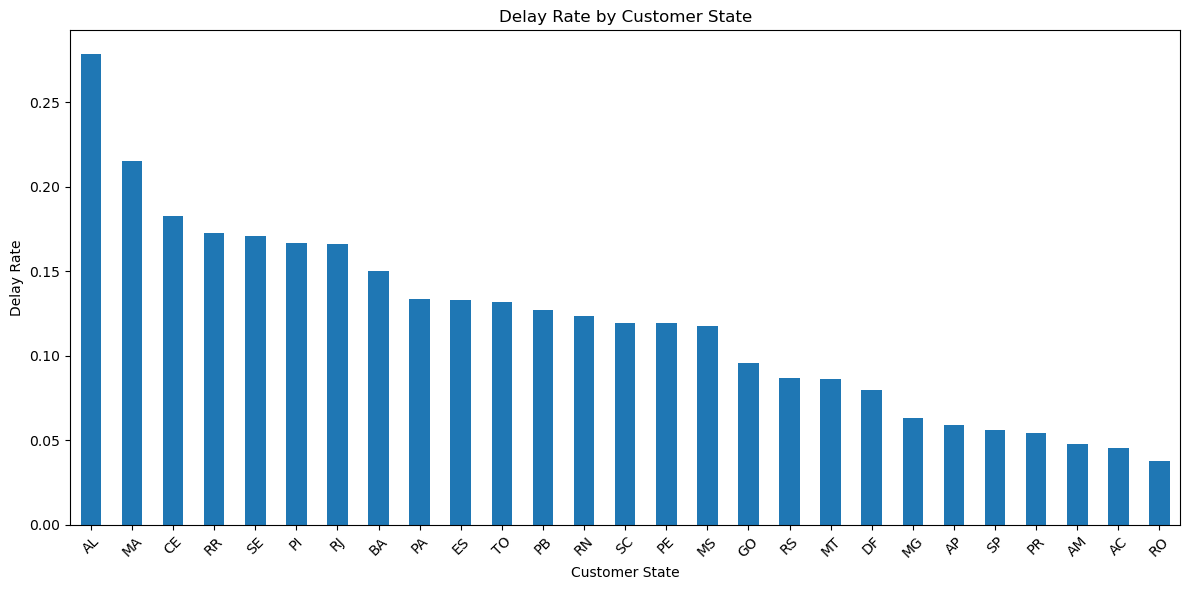

In [17]:
state_delay = (
    train_eda.groupby("customer_state")["is_delayed"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))
state_delay.plot(kind="bar")

plt.title("Delay Rate by Customer State")
plt.xlabel("Customer State")
plt.ylabel("Delay Rate")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    charts_dir / "delay_rate_by_customer_state.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

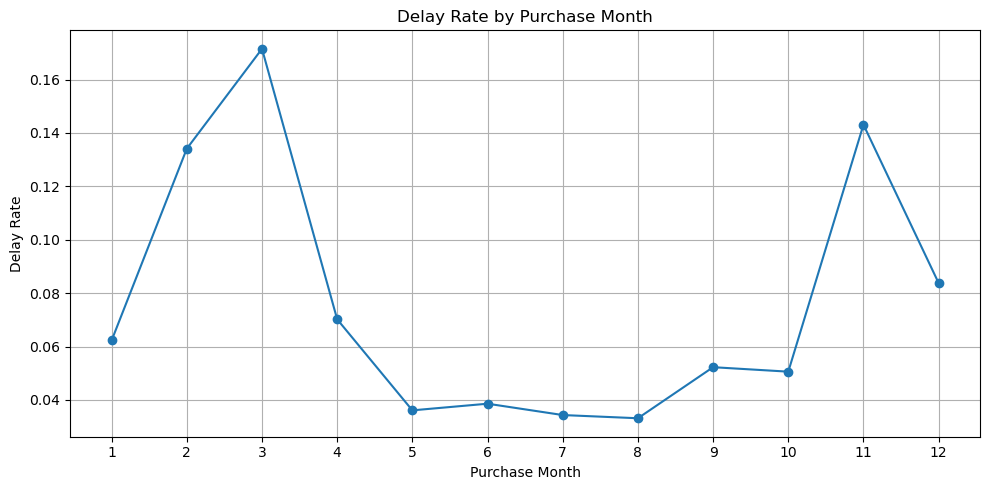

In [18]:
month_delay = (
    train_eda.groupby("purchase_month_num")["is_delayed"]
    .mean()
    .sort_index()
)

plt.figure(figsize=(10, 5))
month_delay.plot(kind="line", marker="o")

plt.title("Delay Rate by Purchase Month")
plt.xlabel("Purchase Month")
plt.ylabel("Delay Rate")
plt.xticks(range(1, 13))
plt.grid(True)
plt.tight_layout()

plt.savefig(
    charts_dir / "delay_rate_by_purchase_month.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

<Figure size 800x500 with 0 Axes>

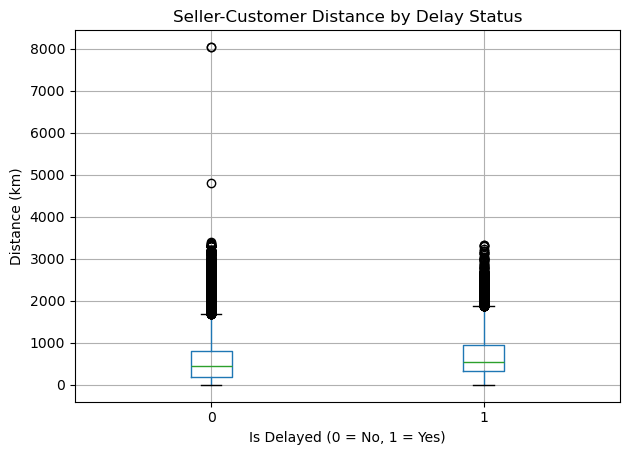

In [19]:
plt.figure(figsize=(8, 5))

train_eda.boxplot(
    column="seller_customer_distance_km",
    by="is_delayed"
)

plt.title("Seller-Customer Distance by Delay Status")
plt.suptitle("")
plt.xlabel("Is Delayed (0 = No, 1 = Yes)")
plt.ylabel("Distance (km)")
plt.tight_layout()

plt.savefig(
    charts_dir / "distance_by_delay_status.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

<Figure size 800x500 with 0 Axes>

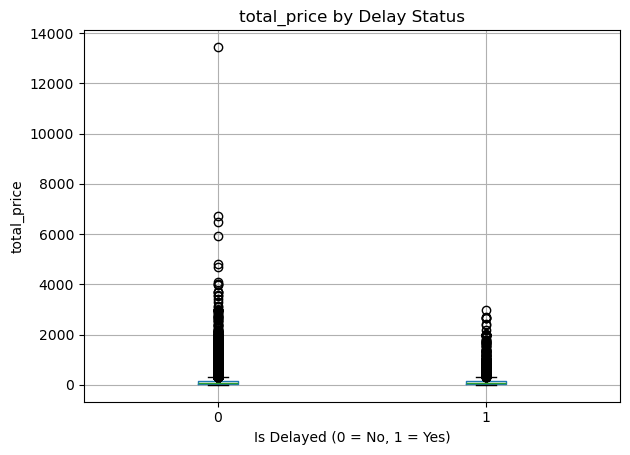

<Figure size 800x500 with 0 Axes>

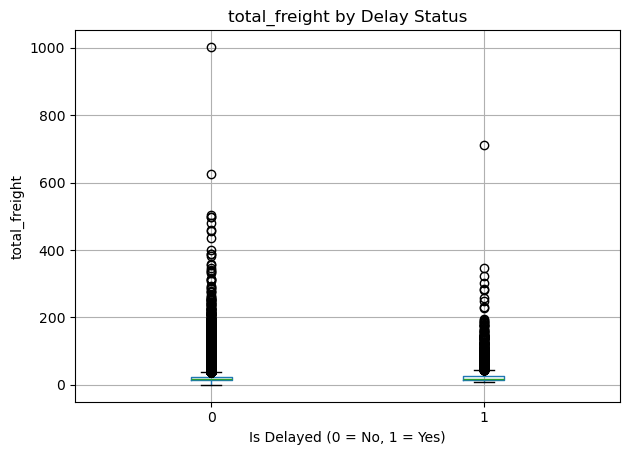

<Figure size 800x500 with 0 Axes>

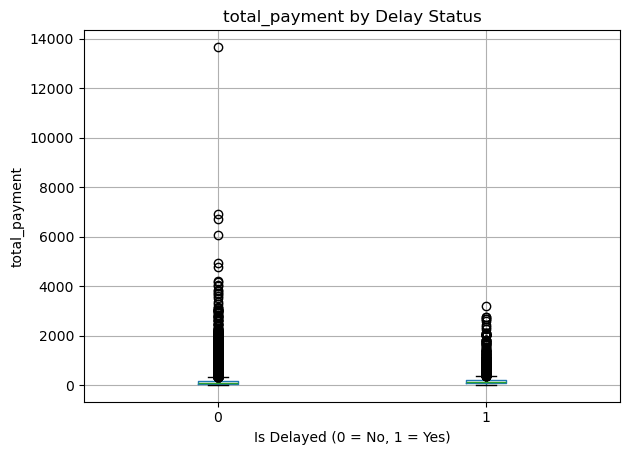

<Figure size 800x500 with 0 Axes>

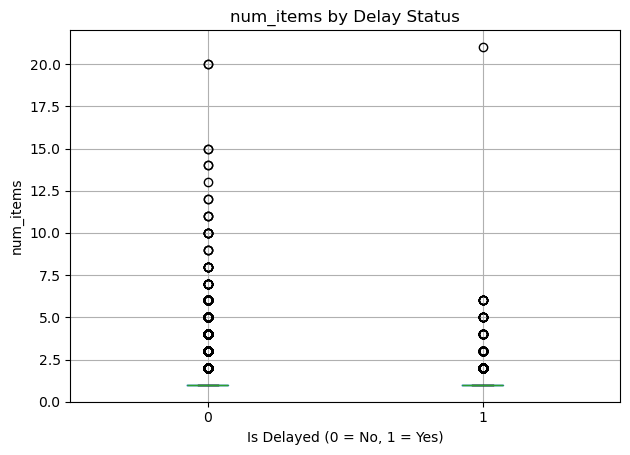

<Figure size 800x500 with 0 Axes>

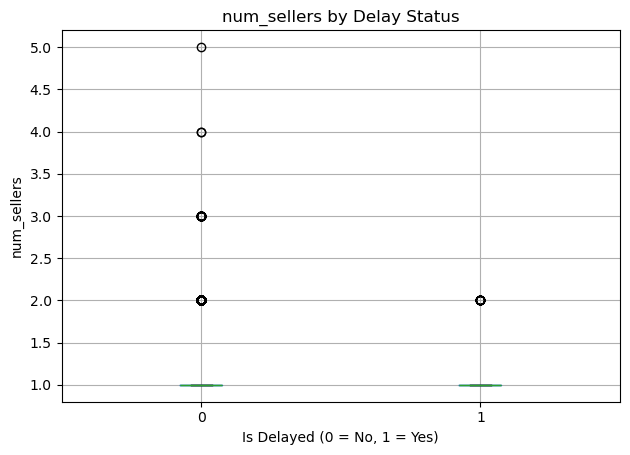

<Figure size 800x500 with 0 Axes>

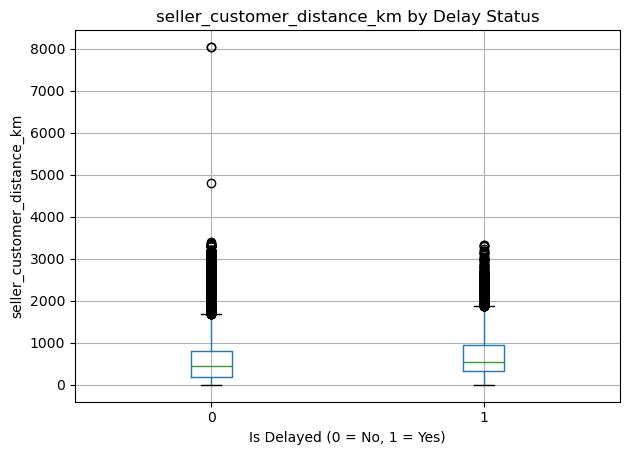

In [20]:
important_numeric = [
    "total_price",
    "total_freight",
    "total_payment",
    "num_items",
    "num_sellers",
    "seller_customer_distance_km"
]

for feature in important_numeric:

    plt.figure(figsize=(8, 5))

    train_eda.boxplot(
        column=feature,
        by="is_delayed"
    )

    plt.title(f"{feature} by Delay Status")
    plt.suptitle("")
    plt.xlabel("Is Delayed (0 = No, 1 = Yes)")
    plt.ylabel(feature)
    plt.tight_layout()

    plt.savefig(
        charts_dir / f"{feature}_by_delay_status.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

In [21]:
print("Saved charts:")

for file in sorted(charts_dir.glob("*.png")):
    print(file)

Saved charts:
data\artifacts\eda\charts\delay_rate_by_customer_state.png
data\artifacts\eda\charts\delay_rate_by_purchase_month.png
data\artifacts\eda\charts\distance_by_delay_status.png
data\artifacts\eda\charts\num_items_by_delay_status.png
data\artifacts\eda\charts\num_sellers_by_delay_status.png
data\artifacts\eda\charts\seller_customer_distance_km_by_delay_status.png
data\artifacts\eda\charts\total_freight_by_delay_status.png
data\artifacts\eda\charts\total_payment_by_delay_status.png
data\artifacts\eda\charts\total_price_by_delay_status.png
